In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
data_dir = 'datasets/EuroSAT_RGB/'
label_names = sorted(os.listdir(data_dir))
label_names.remove('.DS_Store')
label_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [3]:
# count number of images per class
class_counts = {label: len(os.listdir(os.path.join(data_dir, label))) for label in label_names}
class_counts

{'AnnualCrop': 3000,
 'Forest': 3000,
 'HerbaceousVegetation': 3000,
 'Highway': 2500,
 'Industrial': 2500,
 'Pasture': 2000,
 'PermanentCrop': 2500,
 'Residential': 3000,
 'River': 2500,
 'SeaLake': 3000}

## visualize R, G, B

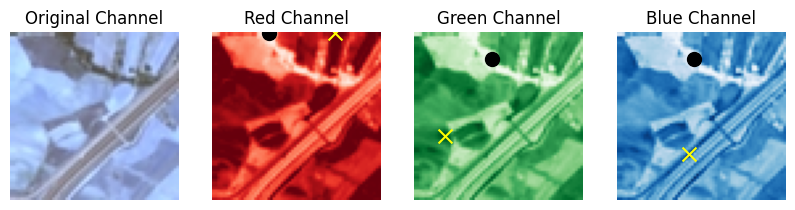

In [4]:
label = label_names[3]
path = os.path.join(data_dir, label, os.listdir(os.path.join(data_dir, label))[0])

img = cv2.imread(path)
B, G, R = cv2.split(img)
titles = ["Original", "Red", "Green", "Blue"]
cmaps = [None, "Reds", "Greens", "Blues"]

# plot the RGB channels
plt.figure(figsize=(10, 6))
for img, color, i in zip([img, R, G, B], ['Original', 'Red', 'Green', 'Blue'], range(4)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap=cmaps[i])
    if color != 'Original':
        max_idx = np.unravel_index(np.argmax(img), img.shape)
        min_idx = np.unravel_index(np.argmin(img), img.shape)
        plt.scatter(max_idx[1], max_idx[0], color='yellow', marker='x', s=100)
        plt.scatter(min_idx[1], min_idx[0], color='black', marker='o', s=100)
    plt.title(f'{color} Channel')
    plt.axis('off')

In [5]:
patch_size = 32
img_quadrants = []
for channel in [R, G, B]:
    for i in range(0, channel.shape[0], patch_size):
        for j in range(0, channel.shape[1], patch_size):
            quadrant = channel[i:i+patch_size, j:j+patch_size]
            img_quadrants.append(quadrant)

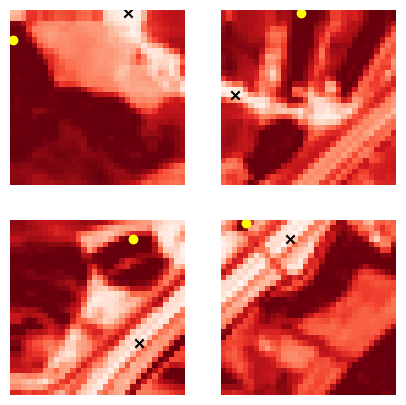

In [6]:
# plot red channel quadrants
plt.figure(figsize=(5, 5))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img_quadrants[i], cmap='Reds')
    # plot max and min pixel values
    # get idx of max and min pixel values
    max_idx = np.unravel_index(np.argmax(img_quadrants[i]), img_quadrants[i].shape)
    min_idx = np.unravel_index(np.argmin(img_quadrants[i]), img_quadrants[i].shape)
    # plot max and min pixel values
    plt.scatter(max_idx[1], max_idx[0], color='yellow', marker='o', label='Max')
    plt.scatter(min_idx[1], min_idx[0], color='black', marker='x', label='Min')
    plt.axis('off')

### feature engineering

In [7]:
def divide_into_quadrants(image, patch_size=32):
    quadrants = []
    for i in range(0, image.shape[0], patch_size):
        for j in range(0, image.shape[1], patch_size):
            quadrant = image[i:i+patch_size, j:j+patch_size]
            quadrants.append(quadrant)
    return quadrants

In [8]:
def compute_stats(path_label):
    path, label = path_label
    img = cv2.imread(path)
    if img is None:
        return None  # skip bad images
    stats = {}
    for i, color in enumerate(['Blue', 'Green', 'Red']):
        channel = img[:, :, i]
        stats[f'{color}_mean'] = channel.mean()
        stats[f'{color}_std'] = channel.std()
        stats[f'{color}_min'] = channel.min()
        stats[f'{color}_max'] = channel.max()

        quadrants = divide_into_quadrants(channel)
        for j, quadrant in enumerate(quadrants):
            stats[f'{color}_quadrant_{j}_mean'] = quadrant.mean()
            stats[f'{color}_quadrant_{j}_std'] = quadrant.std()
            stats[f'{color}_quadrant_{j}_min'] = quadrant.min()
            stats[f'{color}_quadrant_{j}_max'] = quadrant.max()
    
    img_num = os.path.basename(path).split("_")[1].split('.')[0]

    return {
        'image_id': img_num,
        'label': label,
        **stats
    }

In [9]:
# Build list of (path, label)
paths = [
    (os.path.join(data_dir, label, fname), label)
    for label in label_names
    for fname in os.listdir(os.path.join(data_dir, label))
]

# Apply map
data_stats = list(filter(None, map(compute_stats, paths)))

In [10]:
df = pd.DataFrame(data_stats)
df.set_index('image_id', inplace=True)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Blue_quadrant_0_mean,Blue_quadrant_0_std,Blue_quadrant_0_min,Blue_quadrant_0_max,Blue_quadrant_1_mean,...,Red_quadrant_1_min,Red_quadrant_1_max,Red_quadrant_2_mean,Red_quadrant_2_std,Red_quadrant_2_min,Red_quadrant_2_max,Red_quadrant_3_mean,Red_quadrant_3_std,Red_quadrant_3_min,Red_quadrant_3_max
image_id,,,,,,,,,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,122.563477,17.302171,92,160,106.021484,...,57,159,100.156250,40.835357,57,176,160.511719,27.698817,62,207
1372,AnnualCrop,110.764893,22.730603,76,199,116.260742,25.495009,76,199,118.134766,...,58,225,99.659180,35.840059,47,172,103.274414,40.767561,48,221
1366,AnnualCrop,126.442627,22.481973,82,180,121.389648,20.013997,93,165,145.422852,...,105,255,114.382812,24.414230,69,171,185.630859,59.808830,105,255
2109,AnnualCrop,138.062256,26.238712,81,214,144.258789,27.933487,87,214,134.570312,...,81,255,159.750000,43.857858,55,232,170.340820,49.860822,76,255
1400,AnnualCrop,127.583740,16.045508,70,162,124.145508,16.339337,73,162,129.523438,...,63,235,165.315430,37.435819,57,234,180.625000,22.098324,108,233


In [11]:
map_labels2idx = {label: idx for idx, label in enumerate(label_names)}
map_idx2labels = {idx: label for label, idx in map_labels2idx.items()}

In [12]:
df["label_idx"] = df["label"].map(map_labels2idx)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Blue_quadrant_0_mean,Blue_quadrant_0_std,Blue_quadrant_0_min,Blue_quadrant_0_max,Blue_quadrant_1_mean,...,Red_quadrant_1_max,Red_quadrant_2_mean,Red_quadrant_2_std,Red_quadrant_2_min,Red_quadrant_2_max,Red_quadrant_3_mean,Red_quadrant_3_std,Red_quadrant_3_min,Red_quadrant_3_max,label_idx
image_id,,,,,,,,,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,122.563477,17.302171,92,160,106.021484,...,159,100.156250,40.835357,57,176,160.511719,27.698817,62,207,0
1372,AnnualCrop,110.764893,22.730603,76,199,116.260742,25.495009,76,199,118.134766,...,225,99.659180,35.840059,47,172,103.274414,40.767561,48,221,0
1366,AnnualCrop,126.442627,22.481973,82,180,121.389648,20.013997,93,165,145.422852,...,255,114.382812,24.414230,69,171,185.630859,59.808830,105,255,0
2109,AnnualCrop,138.062256,26.238712,81,214,144.258789,27.933487,87,214,134.570312,...,255,159.750000,43.857858,55,232,170.340820,49.860822,76,255,0
1400,AnnualCrop,127.583740,16.045508,70,162,124.145508,16.339337,73,162,129.523438,...,235,165.315430,37.435819,57,234,180.625000,22.098324,108,233,0


In [13]:
# Prepare data for stratified split
X = df[df.columns.difference(['label','label_idx'])].values
y = df['label_idx'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [14]:
# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3]
}

hyp_param_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=2,  # stratified 5-fold cross-validation
    random_state=42,
    n_jobs=-1
)

hyp_param_search.fit(X_train, y_train)

/opt/homebrew/Caskroom/miniconda/base/envs/remote/lib/python3.10/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.1], 'max_depth': [3], 'n_estimators': [50, 100]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [15]:
print("Best Hyperparameters:", hyp_param_search.best_params_)
print("Best CV Score:", hyp_param_search.best_score_)

Best Hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score: 0.7858796296296297


In [16]:
# Train final model with best hyperparameters
best_model = GradientBoostingClassifier(**hyp_param_search.best_params_, random_state=42)
best_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [17]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
report_results = classification_report(y_test, y_pred, target_names=label_names)
print(report_results) 

                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.83      0.83       600
              Forest       0.91      0.94      0.92       600
HerbaceousVegetation       0.75      0.72      0.74       600
             Highway       0.56      0.44      0.49       500
          Industrial       0.87      0.92      0.89       500
             Pasture       0.76      0.82      0.79       400
       PermanentCrop       0.65      0.66      0.65       500
         Residential       0.80      0.86      0.83       600
               River       0.65      0.68      0.66       500
             SeaLake       0.97      0.95      0.96       600

            accuracy                           0.79      5400
           macro avg       0.78      0.78      0.78      5400
        weighted avg       0.78      0.79      0.78      5400



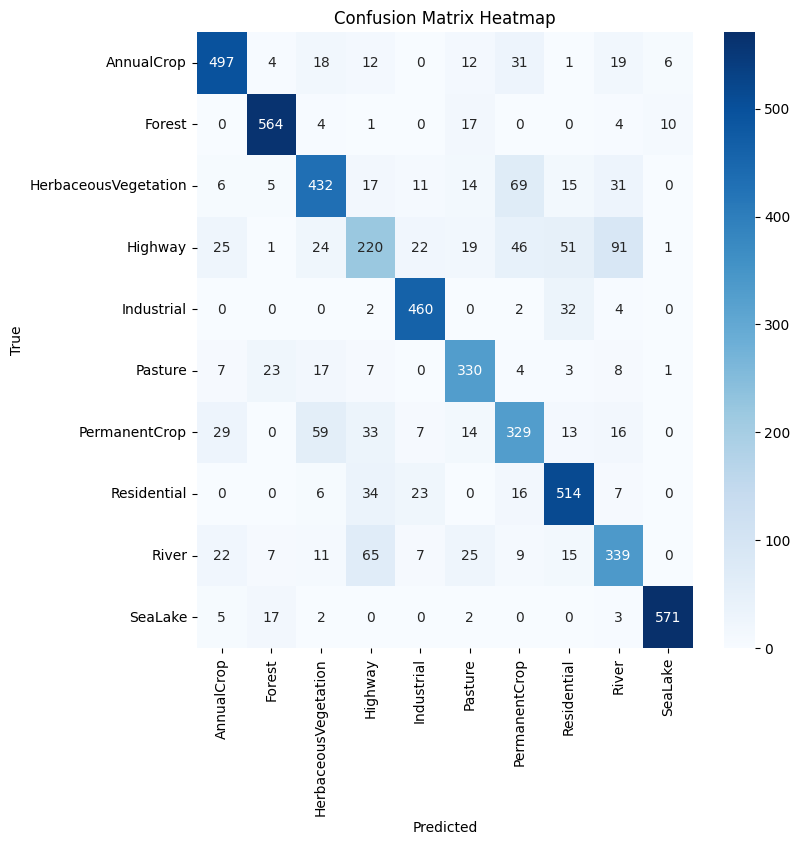

In [18]:
conf_mat_results = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_results, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

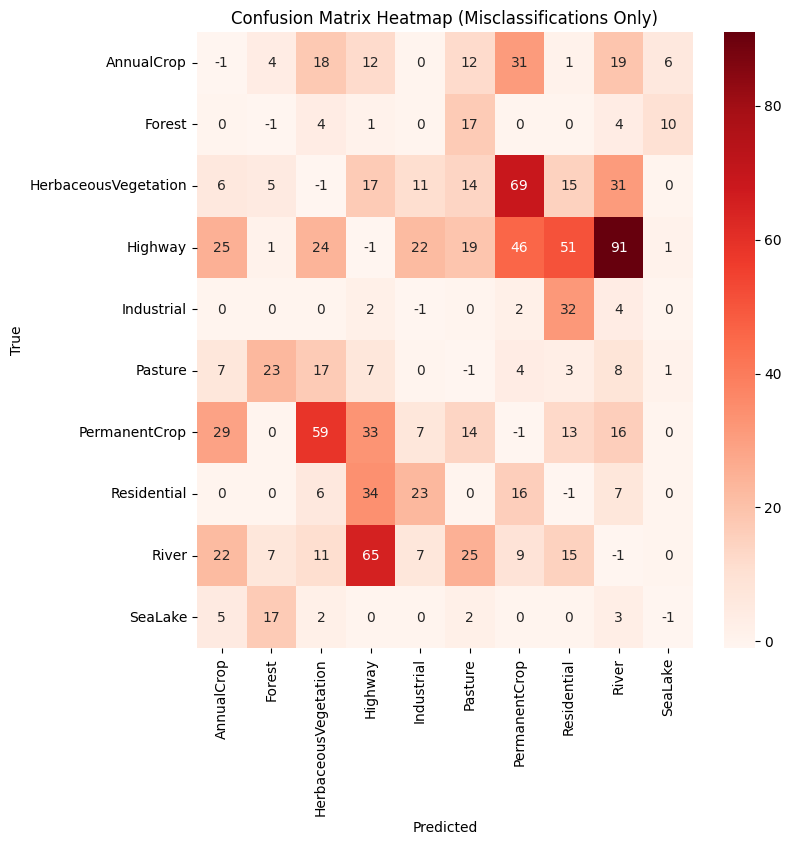

In [19]:
mask = np.eye(conf_mat_results.shape[0], dtype=bool)
conf_mat_masked = np.where(mask, -1, conf_mat_results)

# plot masked confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_masked, annot=True, fmt='d', cmap='Reds', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap (Misclassifications Only)')
plt.show()

In [20]:
# instance-level predictions
test_df = pd.DataFrame(X_test, columns=df.columns.difference(['label','label_idx']))
test_df['true_label_idx'] = y_test
test_df['pred_label_idx'] = y_pred
test_df['true_label'] = test_df['true_label_idx'].map(map_idx2labels)
test_df['pred_label'] = test_df['pred_label_idx'].map(map_idx2labels)
test_df.head()

,Blue_max,Blue_mean,Blue_min,Blue_quadrant_0_max,Blue_quadrant_0_mean,Blue_quadrant_0_min,Blue_quadrant_0_std,Blue_quadrant_1_max,Blue_quadrant_1_mean,Blue_quadrant_1_min,...,Red_quadrant_2_std,Red_quadrant_3_max,Red_quadrant_3_mean,Red_quadrant_3_min,Red_quadrant_3_std,Red_std,true_label_idx,pred_label_idx,true_label,pred_label
0,170.0,116.350830,84.0,159.0,117.323242,91.0,19.236755,165.0,118.451172,88.0,...,34.455164,181.0,97.981445,48.0,37.060242,36.004263,0,3,AnnualCrop,Highway
1,255.0,141.962158,109.0,202.0,127.222656,109.0,12.502782,255.0,134.246094,111.0,...,42.346343,253.0,111.212891,51.0,55.470164,43.616855,4,4,Industrial,Industrial
2,197.0,113.969238,80.0,197.0,93.231445,86.0,11.664840,191.0,116.820312,86.0,...,54.620710,219.0,183.094727,58.0,35.169759,62.697709,0,0,AnnualCrop,AnnualCrop
3,93.0,78.528076,71.0,84.0,77.912109,72.0,2.040146,93.0,78.630859,71.0,...,2.447173,48.0,39.939453,31.0,2.616475,2.988249,1,1,Forest,Forest
4,255.0,139.437012,72.0,255.0,149.504883,79.0,46.085433,255.0,148.725586,72.0,...,54.275838,255.0,133.780273,56.0,47.189379,57.603493,4,4,Industrial,Industrial


In [21]:
test_df_misclassified = test_df[test_df['true_label_idx'] != test_df['pred_label_idx']]
test_df_misclassified.head()

,Blue_max,Blue_mean,Blue_min,Blue_quadrant_0_max,Blue_quadrant_0_mean,Blue_quadrant_0_min,Blue_quadrant_0_std,Blue_quadrant_1_max,Blue_quadrant_1_mean,Blue_quadrant_1_min,...,Red_quadrant_2_std,Red_quadrant_3_max,Red_quadrant_3_mean,Red_quadrant_3_min,Red_quadrant_3_std,Red_std,true_label_idx,pred_label_idx,true_label,pred_label
0,170.0,116.350830,84.0,159.0,117.323242,91.0,19.236755,165.0,118.451172,88.0,...,34.455164,181.0,97.981445,48.0,37.060242,36.004263,0,3,AnnualCrop,Highway
10,255.0,138.882324,87.0,255.0,149.958008,87.0,40.475026,245.0,157.128906,92.0,...,40.125100,255.0,138.284180,80.0,43.038889,49.859839,2,4,HerbaceousVegetation,Industrial
12,255.0,113.484863,89.0,125.0,108.060547,97.0,3.337793,160.0,111.207031,95.0,...,15.546557,255.0,95.835938,47.0,24.329132,15.925251,3,7,Highway,Residential
13,107.0,86.978027,74.0,98.0,86.051758,74.0,3.150871,95.0,85.507812,76.0,...,6.901299,88.0,61.475586,44.0,7.954914,7.214334,1,5,Forest,Pasture
14,255.0,109.679199,79.0,255.0,109.436523,81.0,24.397623,255.0,116.822266,80.0,...,23.650819,208.0,76.143555,40.0,24.286617,31.856820,3,4,Highway,Industrial


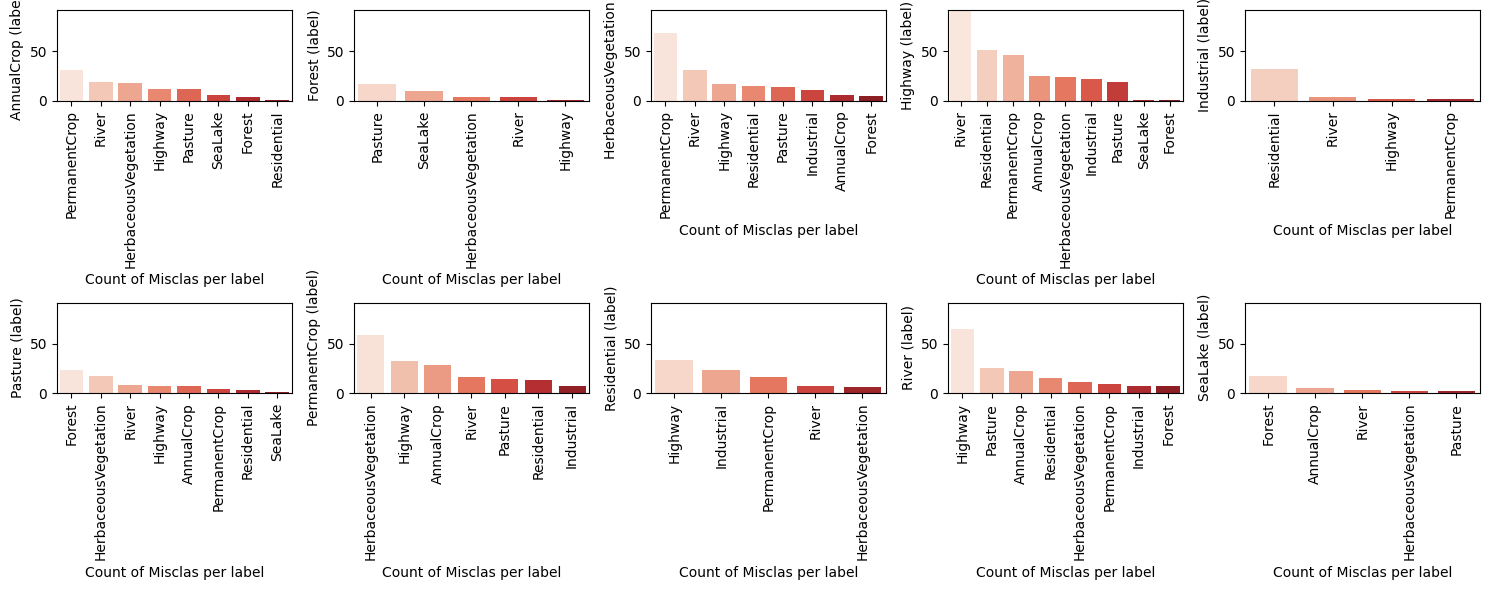

In [22]:
## create list of dict where each dict has keys: true label, other labels count
misclassified_summary = []
for true_label in label_names:
    subset = test_df_misclassified[test_df_misclassified['true_label'] == true_label]
    other_labels_count = subset['pred_label'].value_counts().to_dict()
    misclassified_summary.append({
        'true_label': true_label,
        'other_labels_count': other_labels_count
    })

max_value = 0
for summary in misclassified_summary:
    max_value = max(max_value, max(summary['other_labels_count'].values()))
max_value

# plot misclassification patterns
plt.figure(figsize=(15, 6))
for i, summary in enumerate(misclassified_summary):
    true_label = summary['true_label']
    other_labels_count = summary['other_labels_count']
    plt.subplot(2, 5, i + 1)
    sns.barplot(x=list(other_labels_count.keys()), 
                y=list(other_labels_count.values()), 
                palette='Reds', 
                hue=list(other_labels_count.keys())
        )
    plt.xticks(rotation=90)
    plt.ylabel(f"{true_label} (label)")
    plt.xlabel('Count of Misclas per label')
    plt.ylim(0, max_value + 1)
plt.tight_layout()
plt.show()

### global interpretability

#### impurity-based feature importance

In [23]:
# plot feature importance
feature_importance = best_model.feature_importances_
feature_names = df.columns.difference(['label','label_idx'])
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})   

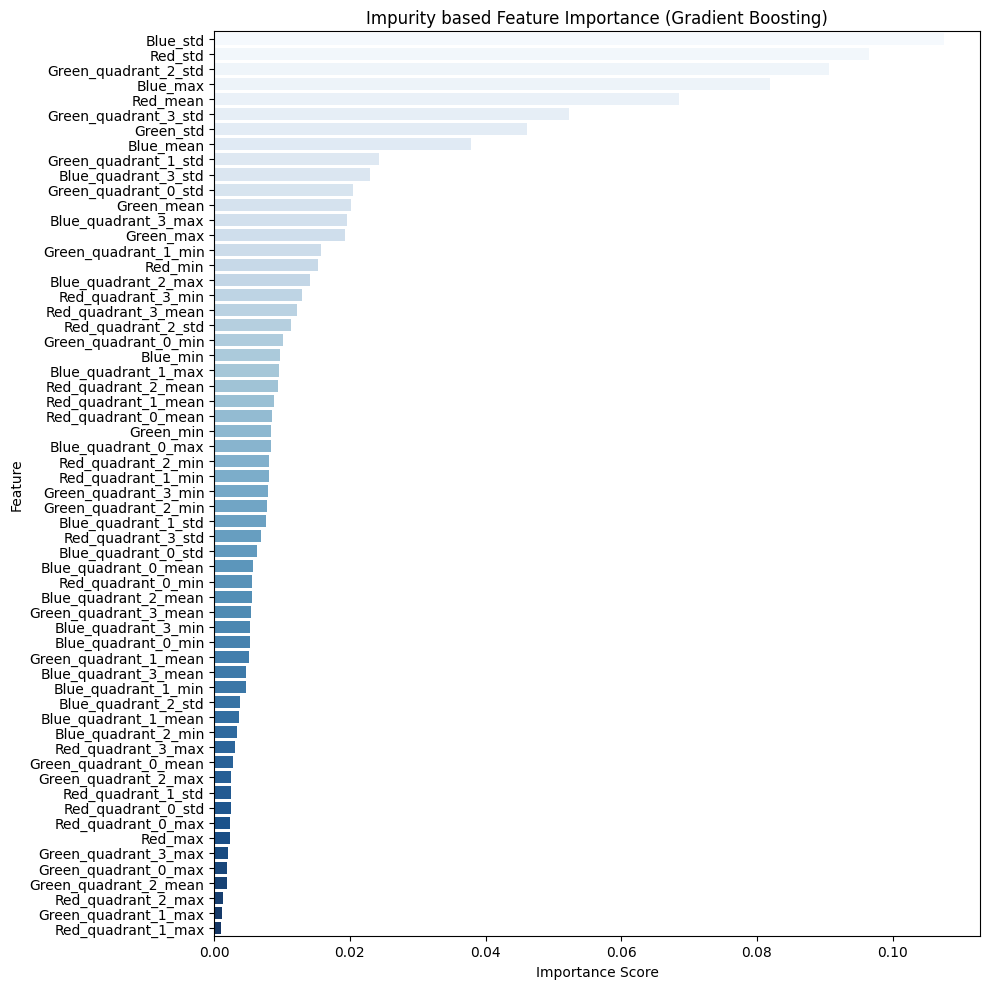

In [24]:
df_plot = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='importance', y='feature', data=df_plot, palette='Blues', hue='feature')
plt.title('Impurity based Feature Importance (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### permutation-based feature importance

In [25]:
from sklearn.inspection import permutation_importance

NUM_REPEATS = 5
RANDOM_STATE = 0

importance_results = permutation_importance(best_model, 
                                            X_train, 
                                            y_train, 
                                            n_repeats=NUM_REPEATS,
                                            random_state=RANDOM_STATE
                                            )

feature_names = df.columns.difference(['label','label_idx'])
feature_importance_df = pd.DataFrame({
                            'feature': feature_names,
                            'importance_mean': importance_results.importances_mean,
                            'importance_std': importance_results.importances_std
                        })

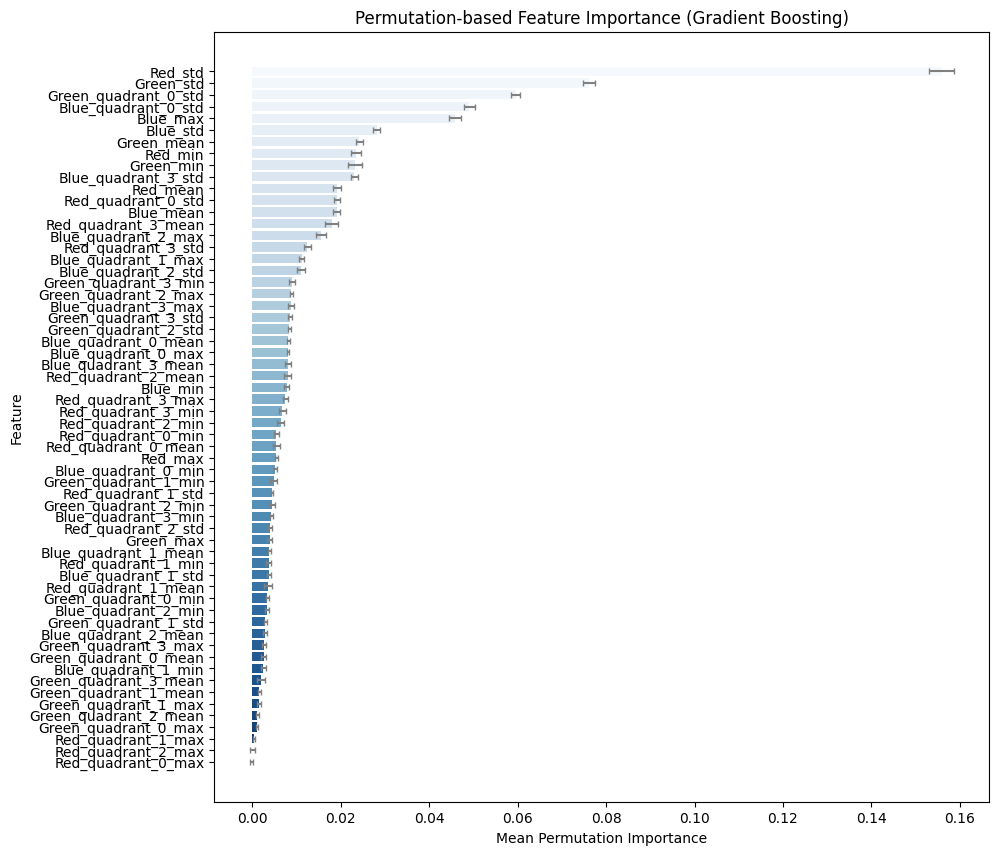

In [26]:
import matplotlib.pyplot as plt

df_plot = feature_importance_df.sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 10))
ax = sns.barplot(data=df_plot, x="importance_mean", y="feature", palette="Blues", orient="h", hue="feature")
ax.errorbar(
            x=df_plot["importance_mean"],
            y=range(len(df_plot)),
            xerr=df_plot["importance_std"],
            fmt="none",
            ecolor="gray",
            capsize=2
            )
ax.set(title="Permutation-based Feature Importance (Gradient Boosting)", xlabel="Mean Permutation Importance", ylabel="Feature")

plt.show()

#### permutation test p-value feature importance

In [ ]:
NUM_PERMUTATIONS = 2

list_permutation_importances = []
for i in range(NUM_PERMUTATIONS):
    y_train_permuted = np.random.permutation(y_train)
    copy_model = GradientBoostingClassifier(**hyp_param_search.best_params_, random_state=42)
    copy_model.fit(X_train, y_train_permuted)
    list_permutation_importances.append(copy_model.feature_importances_)

p_values = []
for i in range(len(feature_names)):
    original_importance = feature_importance[i]
    permuted_importances = [perm[i] for perm in list_permutation_importances]
    p_value = np.mean([1 if perm >= original_importance else 0 for perm in permuted_importances])
    p_values.append(p_value)



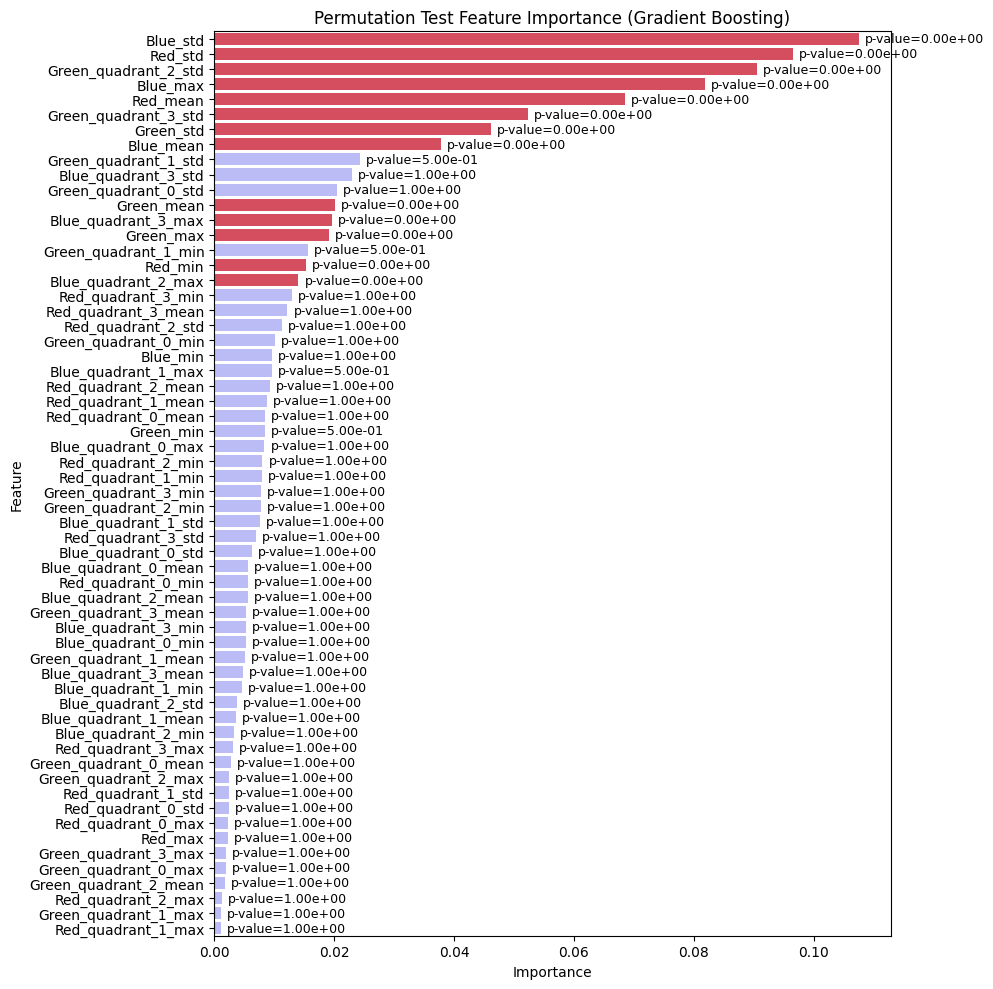

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance,
    "p_value": p_values
})

alpha = 0.05

# Sort once and reset index for consistent plotting
df_plot = feature_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Flag significance
df_plot["significant"] = df_plot["p_value"] < alpha

# Plot
plt.figure(figsize=(10, 10))

# Base bars
ax = sns.barplot(
    data=df_plot,
    x="importance",
    y="feature",
    color="blue",
    orient="h",
    alpha=0.3
)

# Overlay significant ones
sns.barplot(
    data=df_plot[df_plot["significant"]],
    x="importance",
    y="feature",
    color="red",
    orient="h",
    ax=ax,
    alpha=0.7
)

# Annotate p-values
for i, row in df_plot.iterrows():
    ax.text(
        row["importance"] + 0.001,
        i,
        f"p-value={row['p_value']:.2e}",
        va="center",
        fontsize=9
    )

# Labels & title
ax.set_title("Permutation Test Feature Importance (Gradient Boosting)")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()